## Image Caption Generator

To perform Image Captioning we will require two deep learning models combined into one for the training purpose

1. CNNs extract the features from the image of some vector size aka the vector embeddings. The size of these embeddings depend on the type of pretrained network being used for the feature extraction

2. LSTMs are used for the text generation process. The image embeddings are concatenated with the word embeddings and passed to the LSTM to generate the next word


Image Captioning = CNN + RNN
Where:

CNN (e.g., DenseNet, VGG) → encodes the image → outputs a feature vector.

RNN (e.g., LSTM) → decodes that feature into a caption (sequence of words).

Dataset link: https://www.kaggle.com/datasets/adityajn105/flickr8k

### 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tqdm import tqdm

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from textwrap import wrap

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

###2. Load Dataset

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/flickr 8k.zip','r')
zip_ref.extractall ('/content')
zip_ref.close()

In [ ]:
image_path = '/content/Images'
caption_data = pd.read_csv('/content/captions.txt')
caption_data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [ ]:
caption_data.shape

(40455, 2)

###3. Visualize the data images

In [ ]:
# Creating a function to Load and preprocess an image from a given file path

def readImage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))         # Loads the image in RGB mode and resizes it to img_size × img_size
    img = img_to_array(img)                                                       # Converts the PIL image into a NumPy array
    img = img/255.                                                                # Normalizes pixel values from range [0, 255] to [0, 1]
    return img                                                                    # returns normalized image array of shape (224, 224, 3)


# To Plot 15 images with their captions

def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)                                      # Ensures the index is sequential (0 to N-1)
    plt.figure(figsize = (20 , 20))
    n = 0
    for i in range(15):
        n+=1
        plt.subplot(5 , 5, n)
        plt.subplots_adjust(hspace = 0.7, wspace = 0.3)                           # Adds spacing between subplots for readability
        image = readImage(os.path.join(image_path, temp_df.image[i]))
        plt.imshow(image)
        #plt.title(temp_df.caption[i])
        plt.title("\n".join(wrap(temp_df.caption[i], 20)))                        # Wraps the caption to fit in 20-character lines and sets it as the title
        plt.axis("off")

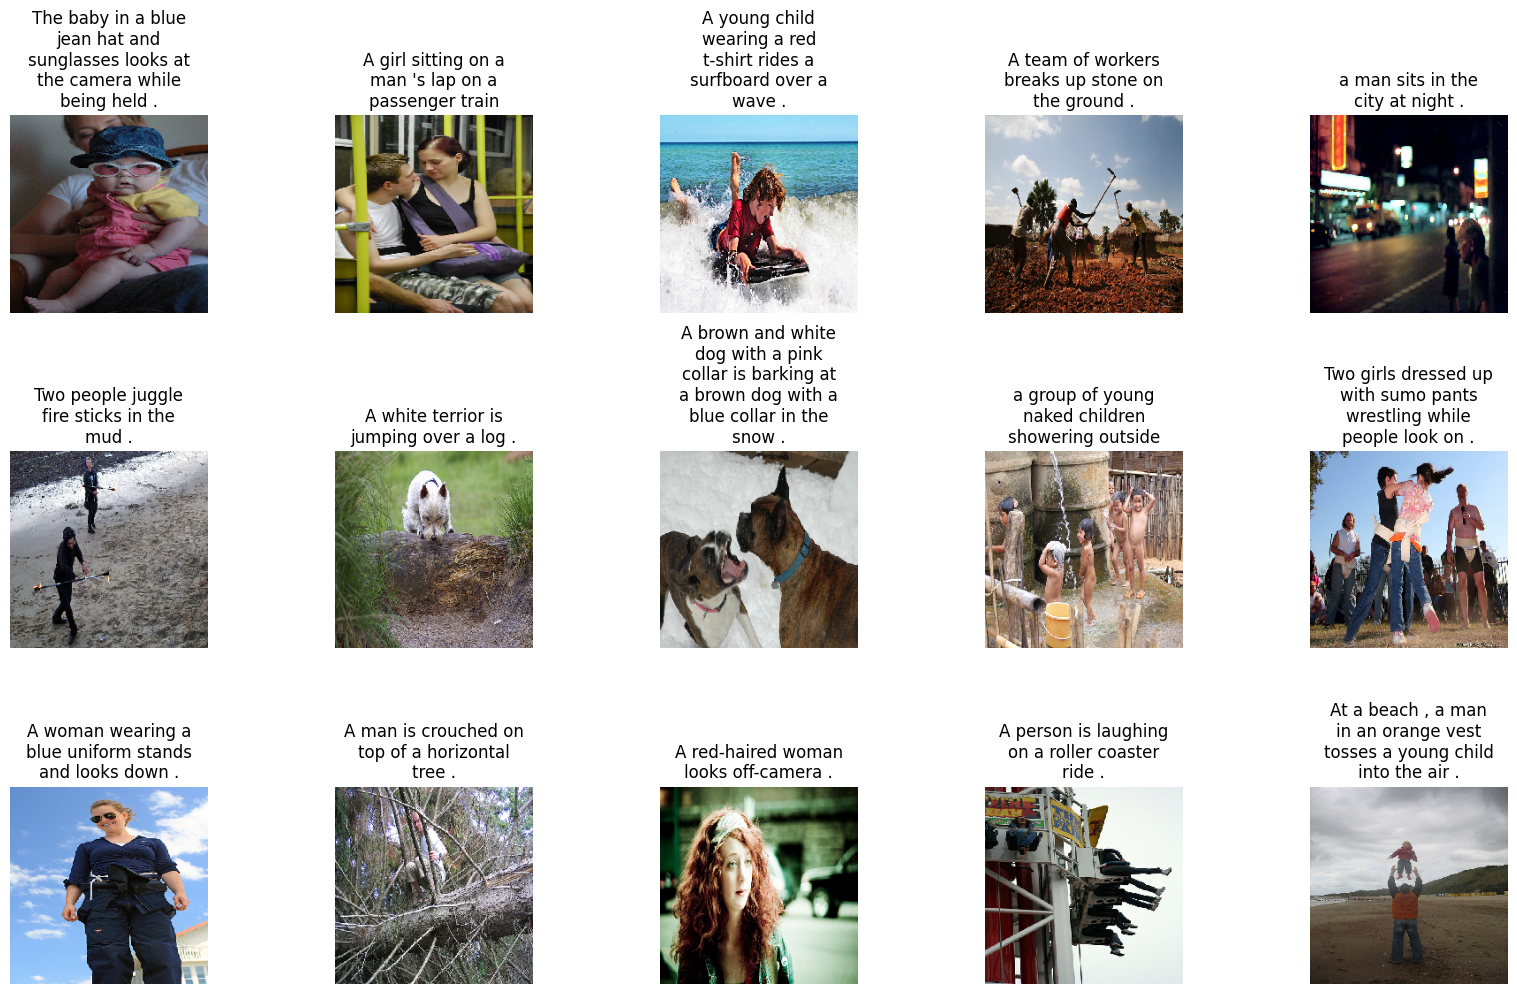

In [ ]:
display_images(caption_data.sample(15))                                           # ensures random selection of images each time — instead of the first 15 rows every time.

###4. Caption text preprocessing

Convert sentences into lowercase

Remove special characters and numbers present in the text

Remove extra spaces

Remove single characters

Add a starting and an ending tag to the sentences to indicate the beginning
and the ending of a sentence

In [ ]:
def text_preprocessing(caption_data):

    # Convert to lowercase
    caption_data['caption'] = caption_data['caption'].apply(lambda x: x.lower())

    # remove punctuation and double spaces and keep only alphabets or numbers
    caption_data['caption'] = caption_data['caption'].apply(lambda x: " ".join("".join(char for char in x if char.isalnum() or char==" ").split()))

    # Adding <start> and <end> tokens
    caption_data['caption'] = 'startseq ' + caption_data['caption'] + ' endseq'

    return caption_data

In [ ]:
# Checking text after performing preprocessing and viewing first 10 captions
caption_data = text_preprocessing(caption_data)
data_tolist = caption_data['caption'].tolist()
data_tolist[:10]

['startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq',
 'startseq a girl going into a wooden building endseq',
 'startseq a little girl climbing into a wooden playhouse endseq',
 'startseq a little girl climbing the stairs to her playhouse endseq',
 'startseq a little girl in a pink dress going into a wooden cabin endseq',
 'startseq a black dog and a spotted dog are fighting endseq',
 'startseq a black dog and a tricolored dog playing with each other on the road endseq',
 'startseq a black dog and a white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

###5. Tokenization

In [ ]:
# separating the words and create indexes for each word

tokenizer = Tokenizer()
tokenizer.fit_on_texts(caption_data["caption"])
tokenizer.word_index

{'a': 1,
 'startseq': 2,
 'endseq': 3,
 'in': 4,
 'the': 5,
 'on': 6,
 'is': 7,
 'and': 8,
 'dog': 9,
 'with': 10,
 'man': 11,
 'of': 12,
 'two': 13,
 'white': 14,
 'black': 15,
 'boy': 16,
 'are': 17,
 'woman': 18,
 'girl': 19,
 'to': 20,
 'wearing': 21,
 'at': 22,
 'people': 23,
 'water': 24,
 'red': 25,
 'young': 26,
 'brown': 27,
 'an': 28,
 'his': 29,
 'blue': 30,
 'dogs': 31,
 'running': 32,
 'through': 33,
 'playing': 34,
 'while': 35,
 'down': 36,
 'shirt': 37,
 'standing': 38,
 'ball': 39,
 'little': 40,
 'grass': 41,
 'child': 42,
 'person': 43,
 'snow': 44,
 'jumping': 45,
 'over': 46,
 'front': 47,
 'three': 48,
 'sitting': 49,
 'holding': 50,
 'field': 51,
 'small': 52,
 'up': 53,
 'by': 54,
 'large': 55,
 'green': 56,
 'group': 57,
 'one': 58,
 'yellow': 59,
 'her': 60,
 'walking': 61,
 'children': 62,
 'men': 63,
 'into': 64,
 'air': 65,
 'beach': 66,
 'near': 67,
 'mouth': 68,
 'jumps': 69,
 'another': 70,
 'for': 71,
 'street': 72,
 'runs': 73,
 'its': 74,
 'from': 75,

In [ ]:
# Counting number of Unique words
vocab_count = len(tokenizer.word_index) +1
vocab_count

8831

In [ ]:
# calculating longest sentence with the maximum number of words
max_len = max([len(x.split()) for x in caption_data["caption"]])
max_len

38

### 6. Splitting image-caption dataset into training and validation sets

While splitting the data here we have to keep in mind that 1 image has 5 captions and while splitting if we split on "split_index = int(0.85 * len(data))" its not right as the same image might appear in both train and test sets, but with different captions.

This means your model could "cheat" and it has seen the image during training, just not that particular caption.

hence we split on unique images.

In [ ]:
# extects unique images from caption_data dataframe because each image can have multiple captions and .tolist() converts the NumPy array to a Python list
unique_images = caption_data['image'].unique().tolist()

# total no of unique images
nimages = len(unique_images)

#splits the data into 75% training and 25% validation sets
split_index = round(0.75*nimages)
train_images = unique_images[:split_index]
val_images = unique_images[split_index:]

#Creating two new DataFrames:
#train: All rows (captions) in the original dataset where the image is in train_images.
#test: All rows(captions) where the image is in val_images.

train = caption_data[caption_data['image'].isin(train_images)]
test = caption_data[caption_data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

In [ ]:
train


,image,caption
0,1000268201_693b08cb0e.jpg,startseq a child in a pink dress is climbing u...
1,1000268201_693b08cb0e.jpg,startseq a girl going into a wooden building e...
2,1000268201_693b08cb0e.jpg,startseq a little girl climbing into a wooden ...
3,1000268201_693b08cb0e.jpg,startseq a little girl climbing the stairs to ...
4,1000268201_693b08cb0e.jpg,startseq a little girl in a pink dress going i...
...,...,...
30335,3523471597_87e0bf3b21.jpg,startseq a couple are looking at an area map e...
30336,3523471597_87e0bf3b21.jpg,startseq a man and woman are standing in front...
30337,3523471597_87e0bf3b21.jpg,startseq tourists examine a sign endseq
30338,3523471597_87e0bf3b21.jpg,startseq two people are reading a sign in fron...


In [ ]:
# Generating sequences (alotting indexes to respective words in the sentences) now that we have indexes
#sequences = tokenizer.texts_to_sequences(caption_data["caption"])


### 7. Image Feature Extraction

📸 Image → 🧠 DenseNet → 📦 Feature Vector (summary of the image)



DenseNet 201 Architecture is used to extract the features from the images
Any other pretrained architecture can also be used for extracting features from these images.

Since the Global Average Pooling layer is selected as the final layer of the DenseNet201 model for our feature extraction, our image embeddings will be a vector of size 1920

In [ ]:
model = DenseNet201()

# Lets create a model fe for feature extraction that will return feature vectors (embeddings) from the second-last layer
# (model.layers[-2] picks the second last layer (usually the Global Average Pooling layer))

fe = Model(inputs=model.input, outputs=model.layers[-2].output)  # fe is Feature_extractor model

img_size = 224
features = {}

for image in tqdm(caption_data['image'].unique()):
  img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))    # image size = (224, 224)
  img = img_to_array(img)                      # Converts the PIL image to a NumPy array → img.shape == (224, 224, 3)
  img = img/255.

  # To add an extra dimension to the image array. CNN models expect input of shape (batch_size, height, width, channels). a single image with shape (224, 224, 3) will be expanded to (1, 224, 224, 3)
  # Even when you're predicting one image, models still expect a batch — so this wraps your single image into a batch of 1.
  img = np.expand_dims(img,axis=0)

  # To pass the image through the CNN to get the 1920-dim feature vector. (feature.shape → (1, 1920))
  feature = fe.predict(img, verbose=0)

  # save the feature vector to this features dict
  features[image] = feature




82524592/82524592 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


100%|██████████| 8091/8091 [15:53<00:00,  8.48it/s]


In [ ]:
# The dictionary features = {image_filename: (1, 1920) feature vector}
features

{'1000268201_693b08cb0e.jpg': array([[7.8687925e-05, 7.3524046e-04, 1.1395992e-03, ..., 5.6523550e-01,
         2.2903734e-01, 6.9639677e-01]], dtype=float32),
 '1001773457_577c3a7d70.jpg': array([[1.2493606e-04, 4.5205752e-04, 1.9292445e-03, ..., 7.4857205e-02,
         2.0473895e+00, 9.0312742e-02]], dtype=float32),
 '1002674143_1b742ab4b8.jpg': array([[5.0414001e-05, 3.7103004e-04, 1.9412232e-03, ..., 8.7596677e-02,
         4.6891612e-01, 3.1746164e-01]], dtype=float32),
 '1003163366_44323f5815.jpg': array([[1.4095566e-04, 7.7881798e-04, 1.2702045e-03, ..., 2.2357759e-01,
         8.1238486e-02, 1.3331179e-01]], dtype=float32),
 '1007129816_e794419615.jpg': array([[9.8224293e-05, 7.2486635e-04, 1.8896528e-03, ..., 1.9271190e+00,
         1.3698294e+00, 1.7164312e-01]], dtype=float32),
 '1007320043_627395c3d8.jpg': array([[1.3486607e-04, 3.0726840e-04, 9.5219788e-04, ..., 2.6253667e-01,
         2.8394485e-02, 1.3737264e+00]], dtype=float32),
 '1009434119_febe49276a.jpg': array([[1.

### 8. Data Generation

Since Image Caption model training like any other neural network training is a highly resource utillizing process we cannot load the data into the main memory all at once, and hence we need to generate the data in the required format batch wise

The inputs will be the image embeddings and their corresonding caption text embeddings for the training process

The text embeddings are passed word by word for the caption generation during inference time

In [ ]:
class CustomDataGenerator(Sequence):

# df: full DataFrame (with image filenames and captions)
# X_col: The column with image filenames
# y_col: The column with captions
# batch_size: How many examples per batch
# directory: Folder where images are stored (not used here directly)
# tokenizer: Keras tokenizer used to convert words to integers
# vocab_count: Number of unique words
# max_length: Max length of input sequences (padding length)
# features: A precomputed dictionary with image names as keys and image features as values (like from DenseNet)
# shuffle: Whether to shuffle the data after every epoch

    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer,
                 vocab_size, max_length, features,shuffle=True):

        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)

    # Every time an epoch finishes, this shuffles the DataFrame if enabled
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    #	Returns the number of batches per epoch: len(dataset)no.of rows // batch_size
    def __len__(self):
        return self.n // self.batch_size

    # Get one batch: Takes a batch slice from the DataFrame and uses __get_data() to build inputs and labels:
    def __getitem__(self,index):

        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)        # X1 → image features    X2 → input sequences of caption   y → next word (output)
        return (X1, X2), y

    # Build batch data and convert it into three arrays : ((image_feature_batch, input_caption_batch), next_word_batch)
    def __get_data(self,batch):
        X1, X2, y = list(), list(), list()
        images = batch[self.X_col].tolist()

        #For each image in the batch, get precomputed DenseNet image features
        for image in images:
            feature = self.features[image][0]
            # For each caption of the image
            captions = batch.loc[batch[self.X_col]==image, self.y_col].tolist()

            # Pull all captions linked to that image
            for caption in captions:
                # For each word pair in the caption -
                seq = self.tokenizer.texts_to_sequences([caption])[0]             #Converts the caption into a sequence of word indices using tokenizer

                # Break caption into: Input: partial sequence (in_seq), Output: next word (out_seq)
                for i in range(1,len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]                                   #Create partial input/output pairs from the sequence
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]         # Pad in_seq to uniform length
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]  #one hot encode out_seq


                    X1.append(feature)                        # Image feature (same for all caption parts)
                    X2.append(in_seq)                         # Caption sequence so far
                    y.append(out_seq)                         # Next word in the caption

        X1, X2, y = np.array(X1), np.array(X2), np.array(y)

        return X1, X2, y



In [ ]:

train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_count,max_length=max_len,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_count,max_length=max_len,features=features)

### 9. Modelling

The image embedding representations are concatenated with the first word of sentence ie. starseq and passed to the LSTM network

The LSTM network starts generating words after each input thus forming a sentence at the end

#### Encoder - Feature extractor model

In [ ]:
from tensorflow.keras.utils import plot_model

# Image Feature Input - Takes 1920-dimensional vector extracted from an image using DenseNet201 with GlobalAveragePooling
input1 = Input(shape=(1920,))

# Image Feature extraction model - Reshape it to shape (1, 256) so it can be concatenated with the caption sequence (which is a sequence of vectors).
fe_layer1 = Dense(256, activation='relu')(input1)
fe_layer2 = Reshape((1, 256), input_shape=(256,))(fe_layer1)


***Why Reshape((1, 256))?***

we are trying to treat the image as the first word in a sequence.
We already passed the image vector through a Dense(256) layer → it's now shape (256,). But LSTMs expect inputs shaped like (timesteps, features)

So you reshape it into a sequence of 1 step with 256 features: → (1, 256)
This makes the image look like the "first word" in a sentence.

#### Encoder - Sequence Model

In [ ]:
# Caption Sequence Input - Takes a sequence of words (as integers) representing the caption so far (up to max_length words)
input2 = Input(shape=(max_len,))

#Caption Processing (Sequence model)- Converts each word index in the caption into a 256-dim vector (like word2vec).Output shape becomes (max_length, 256).
se_layer1 = Embedding(vocab_count, 256, mask_zero=False)(input2)

# Merging Image + Caption- Combines image (1, 256) and caption (max_length, 256) → shape becomes (1 + max_length, 256).
merged = concatenate([fe_layer2, se_layer1], axis=1)


#### Decoder Model - LSTM

In [ ]:
sentence_features = LSTM(256)(merged)
x = Dropout(0.5)(sentence_features)
x = add([x, fe_layer1])   # Combine LSTM output with image again

# Output layers
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocab_count, activation='softmax')(x)
  # Outputs a softmax probability over all vocabulary words — selecting the most likely next word in the caption.


# Final output
caption_model = Model(inputs=[input1,input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy',optimizer='adam')
print(caption_model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1920)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    491,776 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,736 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 39, 256)   │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dropout[0][0],    │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8831)      │  1,139,199 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,449,919 (16.98 MB)

 Trainable params: 4,449,919 (16.98 MB)

 Non-trainable params: 0 (0.00 B)

None


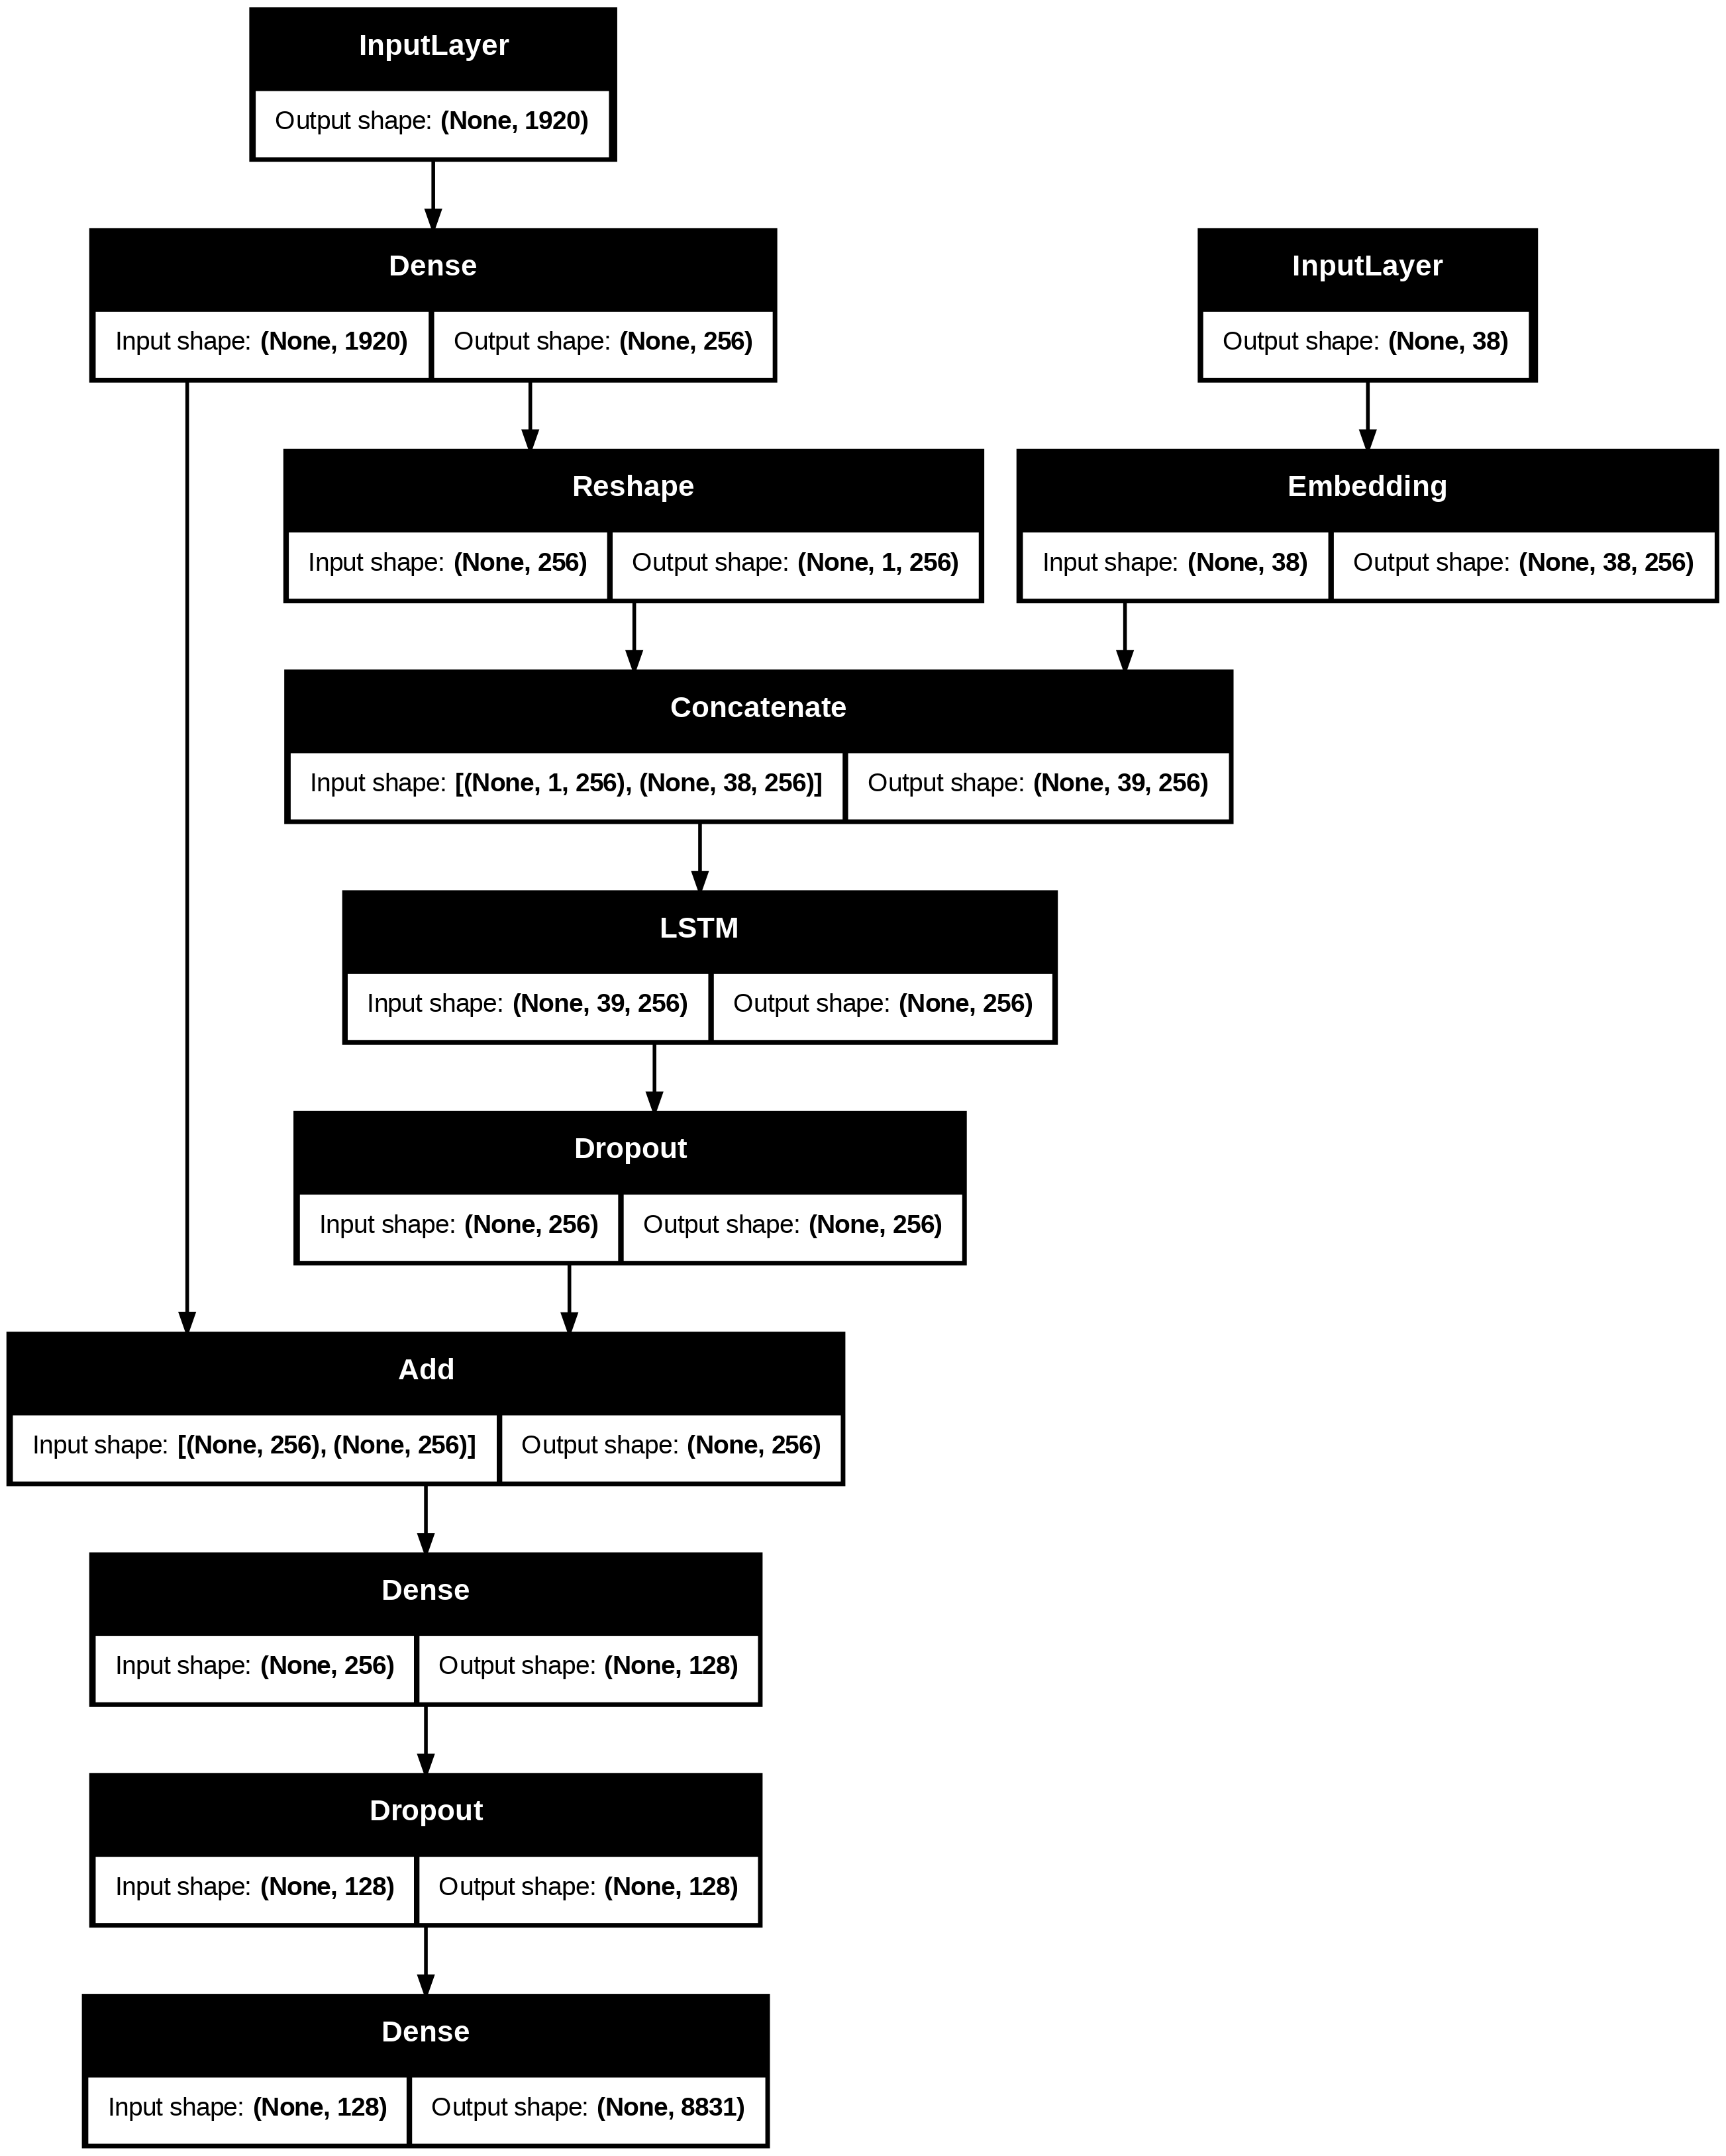

In [ ]:
plot_model(caption_model,show_shapes = True)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Define the model checkpoint
model_name = "model.keras"  # Update the extension to .keras
checkpoint = ModelCheckpoint(
    model_name,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Early Stopping
earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)

history = caption_model.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 5.3541
Epoch 1: val_loss improved from inf to 3.91348, saving model to model.keras
474/474 ━━━━━━━━━━━━━━━━━━━━ 103s 208ms/step - loss: 5.3527 - val_loss: 3.9135 - learning_rate: 0.0010
Epoch 2/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 3.9355
Epoch 2: val_loss improved from 3.91348 to 3.62210, saving model to model.keras
474/474 ━━━━━━━━━━━━━━━━━━━━ 116s 245ms/step - loss: 3.9354 - val_loss: 3.6221 - learning_rate: 0.0010
Epoch 3/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 3.6364
Epoch 3: val_loss improved from 3.62210 to 3.48993, saving model to model.keras
474/474 ━━━━━━━━━━━━━━━━━━━━ 123s 205ms/step - loss: 3.6363 - val_loss: 3.4899 - learning_rate: 0.0010
Epoch 4/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 3.4568
Epoch 4: val_loss improved from 3.48993 to 3.41539, saving model to model.keras
474/474 ━━━━━━━━━━━━━━━━━━━━ 119s 250ms/step - loss: 3.4567 - val_loss: 3.4154 - learning_rate: 0.0

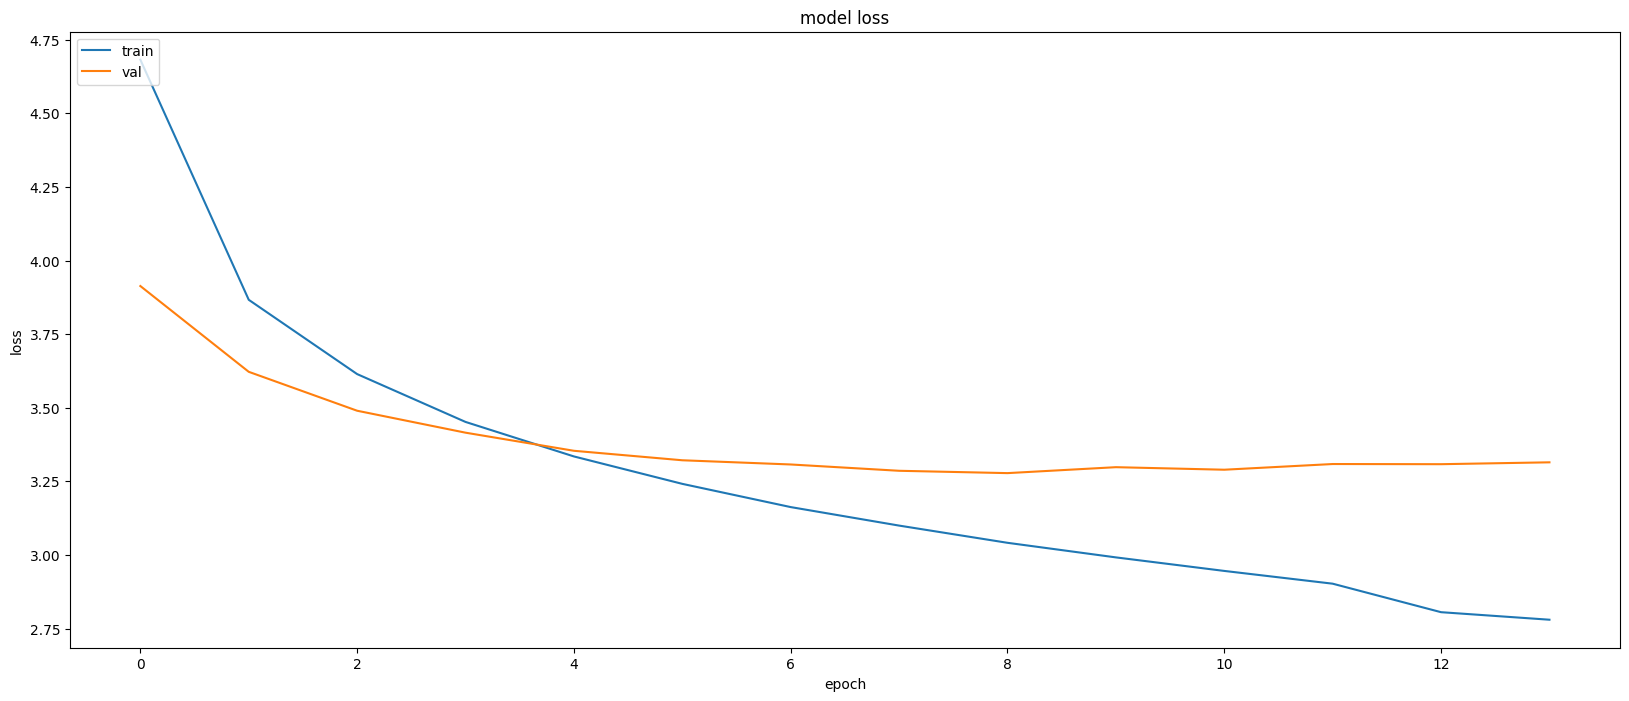

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

### Caption Prediction

In [ ]:
import pickle

# Save the tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save the feature extractor model from DenseNet201
fe.save("feature_extractor.keras")

In [ ]:
# load saved files

model_path = "/content/model.keras"
tokenizer_path = "/content/tokenizer.pkl"
feature_extractor_path = "/content/feature_extractor.keras"


def generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path, max_length=max_len, img_size=224):

    # Load the trained models and tokenizer
    caption_model = load_model(model_path)
    feature_extractor = load_model(feature_extractor_path)
    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)

    # Preprocess the image
    img = load_img(image_path, target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)
    image_features = feature_extractor.predict(img, verbose=0)  # Extract image features

    # Generate the caption
    in_text = "startseq"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = caption_model.predict([image_features, sequence], verbose=0)
        yhat_index = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat_index, None)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    caption = in_text.replace("startseq", "").replace("endseq", "").strip()

    # Display the image with the generated caption
    img = load_img(image_path, target_size=(img_size, img_size))
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=16, color='blue')
    plt.show()

    return caption.split()          # return caption list of words for BLEU score

### Testing on an Image

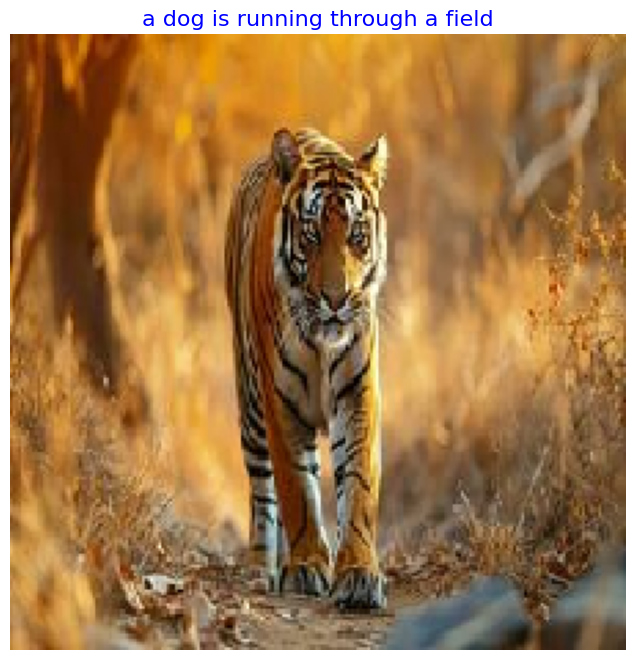

['a', 'dog', 'is', 'running', 'through', 'a', 'field']

In [ ]:
# Testing on an image

image_path = "/content/drive/MyDrive/sample_test_images/2.jpg"
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

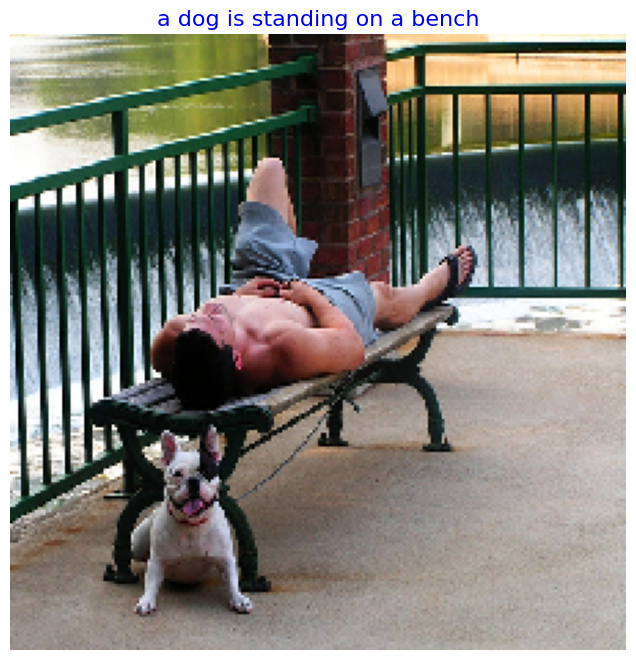

['a', 'dog', 'is', 'standing', 'on', 'a', 'bench']

In [ ]:

image_path = "/content/Images/1003163366_44323f5815.jpg"
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

In [ ]:
# Lets get the original caption from the dataset
reference_captions = caption_data[caption_data['image'] == "1003163366_44323f5815.jpg"]['caption'].tolist()

# Remove <start> and <end> tokens and split
references = [ref.replace('startseq', '').replace('endseq', '').strip().split() for ref in reference_captions]


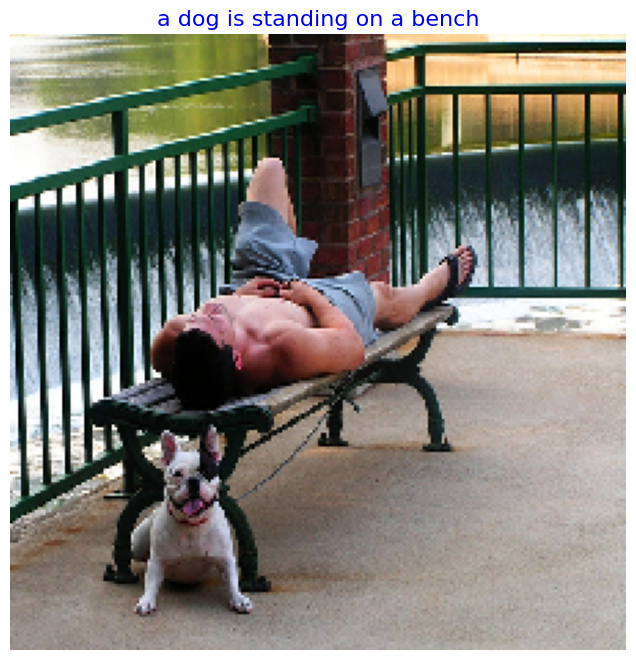

BLEU-1: 0.48404410457807934
BLEU-2: 0.36969479148769485
BLEU-3: 0.25103789467136073
BLEU-4: 0.14350291570059803


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Generate the predicted caption
generated = generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

# Compute BLEU scores between the originals and predicted captions:

smoothie = SmoothingFunction().method4
print("BLEU-1:", sentence_bleu(references, generated, weights=(1, 0, 0, 0), smoothing_function=smoothie))
print("BLEU-2:", sentence_bleu(references, generated, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie))
print("BLEU-3:", sentence_bleu(references, generated, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie))
print("BLEU-4:", sentence_bleu(references, generated, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie))

### Conclusion:

The model is overfitting as the loss reduces on training daya but plateus on validation data and eventually the training stops at 14 epochs using early stopping.

BLEU-4 scores suggest improvemnt as they are very low 0.1

Improvements can be made by:
- Using larger datasets
- Training for higher number of epochs
- Using Attention model or transformers
